In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

Load Dataset

In [33]:
df = pd.read_parquet("dataset.parquet")

print(df.shape)

(564, 334)


Select important raw signals

In [34]:
selected_signals = [
    "DXP_Inj1PrsAct",
    "DXP_Inj1VelAct",
    "DXP_Inj1PosAct",
    "DXP_MldCavPrs1Act"
]

Select labels

In [35]:
label_cols = [
    "LBL_SinkMarks",
    "LBL_SprueCircle",
    "LBL_StreaksLevel1",
    "LBL_StreaksLevel2",
    "LBL_Underfilled",
    "LBL_OldGranulate"
]

label_cols = [c for c in label_cols if c in df.columns]

y = df[label_cols].fillna(0).values

print(y.shape)
print(label_cols)

(564, 6)
['LBL_SinkMarks', 'LBL_SprueCircle', 'LBL_StreaksLevel1', 'LBL_StreaksLevel2', 'LBL_Underfilled', 'LBL_OldGranulate']


Resample signals to fixed length

In [36]:
def resample_signal(signal, target_len=500):
    signal = np.array(signal, dtype=float)
    old_index = np.linspace(0, 1, len(signal))
    new_index = np.linspace(0, 1, target_len)
    return np.interp(new_index, old_index, signal)

Prepare Input Tensor

In [37]:
target_len = 500

X_list = []

for _, row in df.iterrows():
    cycle_signals = []

    for signal in selected_signals:
        resampled = resample_signal(row[signal], target_len)
        cycle_signals.append(resampled)

    cycle_signals = np.stack(cycle_signals, axis=1)
    X_list.append(cycle_signals)

X = np.array(X_list)

print(X.shape)

(564, 500, 4)


Train-test split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (451, 500, 4)
X_test: (113, 500, 4)
y_train: (451, 6)
y_test: (113, 6)


## Data Normalization

The training and testing datasets are standardized using `StandardScaler`.  
The time-series data are reshaped to two dimensions for scaling and then reshaped back to their original three-dimensional format. This ensures that all input features are on a similar scale before training the TCN model.

In [39]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train = X_train_scaled.reshape(X_train.shape)
X_test = X_test_scaled.reshape(X_test.shape)

print(X_train.shape)
print(X_test.shape)

(451, 500, 4)
(113, 500, 4)


Build TCN-Inspired Model

In [40]:
model = models.Sequential([
    layers.Input(shape=(target_len, len(selected_signals))),

    layers.Conv1D(64, kernel_size=5, padding="causal", dilation_rate=1, activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(64, kernel_size=5, padding="causal", dilation_rate=2, activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(64, kernel_size=5, padding="causal", dilation_rate=4, activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(len(label_cols), activation="sigmoid")
])


model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 500, 64)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 500, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 500, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,750 (186.52 KB)

 Trainable params: 47,366 (185.02 KB)

 Non-trainable params: 384 (1.50 KB)

## Train the TCN-Inspired Model

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - binary_accuracy: 0.7356 - loss: 0.5514 - precision: 0.1950 - recall: 0.5707 - val_binary_accuracy: 0.8718 - val_loss: 0.5810 - val_precision: 0.2727 - val_recall: 0.2400
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.8833 - loss: 0.3721 - precision: 0.3842 - recall: 0.3805 - val_binary_accuracy: 0.9084 - val_loss: 0.4753 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.9144 - loss: 0.2640 - precision: 0.5794 - recall: 0.3561 - val_binary_accuracy: 0.9084 - val_loss: 0.3924 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.9060 - loss: 0.2362 - precision: 0.5094 - recall: 0.2634 - val_binary_accuracy: 0.9139 - val_loss: 0.3250 - val_precision: 0.6000 - val_recall: 0.1800
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - binary_accuracy: 0.9190 - loss: 0.2023 

## Training Loss Visualization

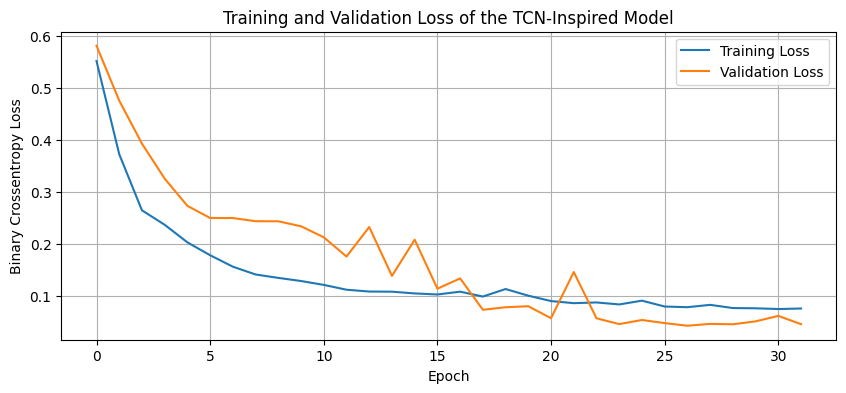

In [42]:
plt.figure(figsize=(10,4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Training and Validation Loss of the TCN-Inspired Model")
plt.legend()
plt.grid(True)
plt.show()

The model was evaluated on the test dataset using precision, recall, and F1-score for each defect class.

## Model Evaluation Metrics

In [43]:
# Threshold 0.5 is used as the baseline decision threshold
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_cols,
    zero_division=0
))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
                   precision    recall  f1-score   support

    LBL_SinkMarks       1.00      1.00      1.00        36
  LBL_SprueCircle       0.70      0.94      0.80        17
LBL_StreaksLevel1       1.00      0.88      0.93         8
LBL_StreaksLevel2       0.67      1.00      0.80         2
  LBL_Underfilled       1.00      0.58      0.74        12
 LBL_OldGranulate       0.00      0.00      0.00         2

        micro avg       0.89      0.88      0.89        77
        macro avg       0.73      0.73      0.71        77
     weighted avg       0.90      0.88      0.88        77
      samples avg       0.49      0.49      0.49        77



## Model Evaluation

The TCN-inspired model was evaluated on the test dataset using precision, recall, and F1-score for each defect class.

The model achieved excellent performance for common defect classes. It obtained an F1-score of **1.00** for **LBL_SinkMarks**, **0.93** for **LBL_StreaksLevel1**, **0.80** for **LBL_StreaksLevel2**, and **0.74** for **LBL_Underfilled**. The model also detected **LBL_SprueCircle** with perfect precision but moderate recall (F1-score = **0.64**).

The rare defect class **LBL_OldGranulate** was not detected because only a few positive samples were available for training, highlighting the effect of severe class imbalance.

Overall, the model achieved a **micro F1-score of 0.87**, **macro F1-score of 0.69**, and **weighted F1-score of 0.84**, demonstrating that the TCN-inspired architecture effectively learned temporal patterns from the manufacturing sensor signals.

## Conclusion

A TCN-inspired deep learning model was developed to classify multiple manufacturing defects using raw time-series sensor data. The model successfully learned temporal patterns from four key DXP sensor signals after resampling and normalization.

The results demonstrate strong performance for the major defect classes, while prediction of rare defects remains challenging because of the highly imbalanced dataset. Overall, the proposed TCN-inspired model provides an effective deep learning baseline for industrial time-series defect classification and serves as a useful comparison with traditional machine learning approaches such as XGBoost.